### Build a Basic Chatbot with Langgraph(GRAPH API)

In [10]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [11]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # in this case, it appends messages to the list, rather than overwriting them
    messages: Annotated[list, add_messages]



In [12]:
import os
from dotenv import load_dotenv
load_dotenv()
Groq_API_KEY=os.environ["GROQ_API_KEY"]

python-dotenv could not parse statement starting at line 1


In [13]:
from langchain_groq import ChatGroq

from langchain.chat_models import init_chat_model

# llm=ChatGroq(model="llama3-8b-8192")

In [14]:
llm = init_chat_model("groq:qwen/qwen3.6-27b")

response = llm.invoke("What is the date today? and why it's a special day for india?")
response.content

NotFoundError: Error code: 404 - {'error': {'message': 'The model `qwen/qwen3.6-27b` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [ ]:
graph_builder = StateGraph(State)

In [ ]:
## Node functionality

def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot) # Node name, function

## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## Compile the graph
graph = graph_builder.compile()

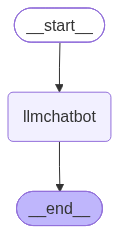

In [ ]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Hey")


In [ ]:
response = graph.invoke({"messages":"Hi"})

In [ ]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a simple greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or request is made.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Keep it open-ended to encourage further interaction\n   - Maintain a friendly, helpful tone\n   - Match the simplicity of the input\n4.  **Draft Response (Mental):** "Hello! How can I help you today?" or "Hi there! What\'s on your mind?" or "Hello! How can I assist you?"\n5.  **Refine Response:** Keep it concise and welcoming. "Hello! How can I help you today?" is standard, effective, and open-ended.\n6.  **Final Output Generation:** Match the refined response.✅\n</think>\n\nHello! How can I help you today? 😊'

In [ ]:
for event in graph.stream({"messages":"Hi how are you"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi how are you"\n   - This is a standard greeting and a common conversational opener.\n   - It\'s informal and friendly.\n\n2.  **Identify Key Elements:**\n   - Greeting: "Hi"\n   - Question: "how are you"\n   - Expected response: Acknowledge greeting, respond to the question politely, and invite further conversation.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the greeting warmly\n   - State that I\'m doing well (as an AI, I don\'t have feelings, but I can phrase it appropriately)\n   - Ask how they\'re doing\n   - Offer assistance\n   - Keep it concise and friendly\n\n4.  **Draft Response (Mental):**\n   Hi! I\'m doing well, thank you for asking. How are you doing today? Is there anything I can help you with?\n\n5.  **Refine Response:**\n   - Check tone: Friendly, professional, helpful\n   - Check accuracy: Acknowledge AI nature implici

# Chatbot with tool 


In [ ]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is langgraph")



{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.95386744,
   'raw_content': None,
   'id': 'cfc828-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? | IBM'

In [ ]:
def multiply(a:int, b:int)->int:
    """Multiplies two integers and returns the result.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The product of the two integers.
    """

In [15]:
tools=[tool,multiply]

In [17]:
llm_with_tools = llm.bind_tools(tools)

In [19]:
llm_with_tools 

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x7a3bbc787890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7a3bbc586a20>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, '

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",)
builder.add_node("tools",ToolNode(tools))

## Add Edges
